# Intermediate integration - multi-branch MLP regressor

This notebook implements a multi-branch MLP regressor using the intermediate integration approach. In this approach, each input modality is processed through its own branch of the network, and the outputs of these branches are concatenated and passed through additional layers to produce the final output.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
import pyarrow
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from itertools import product
from captum.attr import DeepLiftShap
from torchviz import make_dot
from torchview import draw_graph
import random

seed = 6542
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [2]:
project_root = Path.cwd().parent
print(project_root)

c:\Users\joddy\repos\multiomics_integration_publication


## Data processing

These first steps import the same data that has been processed in the late_integration notebook. More details on the processing of that data can be traced back to that notebook.

In [9]:
# import pre-processed data
lcms_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' / 'lcms_data_modelling.feather')
miRNA_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' /  'mirna_data_modelling.feather')
olink_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' / 'olink_data_modelling.feather')
combined_metadata = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'combined_metadata.feather')
run_3_nk_cell_proportions = pd.read_csv(project_root / '00_data' / 'nk_cell_percentages_run_3.csv')
run_4_nk_cell_proportions = pd.read_csv(project_root / '00_data' / 'nk_cell_proportions_run_4.csv')

In [ ]:
# add run number to proportions data
run_3_nk_cell_proportions['run'] = 3
run_4_nk_cell_proportions['run'] = 4

In [12]:
# Extract vessel and day numbers
# first remove nk_cell_count and total_cells and Unnamed: 0 columns from run_4_nk_cell_proportions
run_3_nk_cell_proportions[['vessel', 'day']] = run_3_nk_cell_proportions['vessel_day'].str.extract(r'V(\d+)_D(\d+)')
run_3_nk_cell_proportions['vessel'] = pd.to_numeric(run_3_nk_cell_proportions['vessel'])
run_3_nk_cell_proportions['day'] = pd.to_numeric(run_3_nk_cell_proportions['day'])
run_3_nk_cell_proportions['label'] = 'r' + run_3_nk_cell_proportions['run'].astype(str) + '_v' + run_3_nk_cell_proportions['vessel'].astype(str) + '_d' + run_3_nk_cell_proportions['day'].astype(str)

In [11]:
# Extract vessel and day numbers
# first remove nk_cell_count and total_cells and Unnamed: 0 columns from run_4_nk_cell_proportions
run_4_nk_cell_proportions = run_4_nk_cell_proportions.drop(columns=['nk_cell_count', 'total_cells', 'Unnamed: 0'])
run_4_nk_cell_proportions[['vessel', 'day']] = run_4_nk_cell_proportions['vessel_day'].str.extract(r'V(\d+)_D(\d+)')
run_4_nk_cell_proportions['vessel'] = pd.to_numeric(run_4_nk_cell_proportions['vessel'])
run_4_nk_cell_proportions['day'] = pd.to_numeric(run_4_nk_cell_proportions['day'])
# extract run from column instead of hardcoding
run_4_nk_cell_proportions['label'] = 'r' + run_4_nk_cell_proportions['run'].astype(str) + '_v' + run_4_nk_cell_proportions['vessel'].astype(str) + '_d' + run_4_nk_cell_proportions['day'].astype(str)

In [13]:
# bind rows of the two runs of nk cell proportions together
nk_cell_proportions = pd.concat([run_3_nk_cell_proportions, run_4_nk_cell_proportions], ignore_index=True)

In [ ]:
# Set index to 'label' and drop the column for all modalities
miRNA_data.index = miRNA_data['label']
miRNA_data = miRNA_data.drop(columns=['label'])

olink_data.index = olink_data['label']
olink_data = olink_data.drop(columns=['label'])

lcms_data.index = lcms_data['label']
lcms_data = lcms_data.drop(columns=['label'])

target_variable = nk_cell_proportions[['proportion_NK', 'label']]
target_variable.index = target_variable['label']
target_variable = target_variable.drop(columns=['label'])

# Sort all omics data by their index in alphanumeric order
olink_data = olink_data.sort_index()
miRNA_data = miRNA_data.sort_index()
lcms_data = lcms_data.sort_index()
target_variable = target_variable.sort_index()

False
False
False


## Multi-branch MLP regressor

The steps below first set up the masks which provide information regarding whether data is present or absent for a particular feature. The individual branches of the network are then defined (MaskedBranch), followed by the combination of these branches into a larger network (MultiBranchMLP).

The size of the hidden dimensions within the branches are set in proportion to the number of features from each branch (so that more information can be captured from branches with more features). The final hidden layer is set to be the sum of the hidden dimensions of each branch, and the output layer is a single node (since this is a regression task).

In [15]:
modalities = [miRNA_data, olink_data, lcms_data]
target = target_variable['proportion_NK']

# Align sample IDs across all modalities and target (union of all sample IDs)
all_ids = sorted(set().union(*[df.index for df in modalities], target.index))
modality_matrices, modality_masks = [], []

for df in modalities:
    df_aligned = df.reindex(all_ids).fillna(0.0)
    mask = (~df.reindex(all_ids).isna()).astype(float).values
    modality_matrices.append(torch.tensor(df_aligned.values, dtype=torch.float32))
    modality_masks.append(torch.tensor(mask, dtype=torch.float32))

target_aligned = target.reindex(all_ids).values.astype(np.float32)
target_tensor = torch.tensor(target_aligned, dtype=torch.float32)

In [42]:
class MaskedBranch(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        # Input dimension doubles because we append the mask
        self.net = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

    def forward(self, x, mask):
        # Concatenate feature values and mask
        x_masked = torch.cat([x, mask], dim=1)
        return self.net(x_masked)

class MultiBranchMLP(nn.Module):
    def __init__(self, input_dims, hidden_dim=64, final_hidden=64, min_branch_hidden=4):
        super().__init__()

        # Compute average number of features across branches
        avg_features = np.mean(input_dims)

        # Compute hidden size for each branch proportional to number of features
        branch_hidden_dims = [
            max(int(hidden_dim * d / avg_features), min_branch_hidden) 
            for d in input_dims
        ]

        # Create branches
        self.branches = nn.ModuleList([
            MaskedBranch(d, h) for d, h in zip(input_dims, branch_hidden_dims)
        ])

        # Final fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(sum(branch_hidden_dims), final_hidden),
            nn.ReLU(),
            nn.Linear(final_hidden, 1)
        )

    def forward(self, Xs, Masks):
        branch_outs = [branch(x, m) for branch, x, m in zip(self.branches, Xs, Masks)]
        combined = torch.cat(branch_outs, dim=1)
        return self.fc(combined).squeeze(1)


# Nested cross-validation

Having defined the model architecture above, the nested cross-validation procedure is implemented below. The outer loop splits the data into training and test sets (using five-fold cross-validation), while the inner loop performs hyperparameter tuning using three-fold cross-validation on the training set. The best hyperparameters are selected based on the inner loop performance, and the model is then evaluated on the outer test set.

The hyperparameters selected for tuning here are the learning rate, size of the hidden dimensions, and size of the final hidden layer (the three options for these can be seen below). The performance metric used for evaluation is the mean squared error (MSE).

In [43]:
def train_one_fold(model, optimizer, criterion, Xs_train, Ms_train, y_train, Xs_val, Ms_val, y_val, num_epochs=100, device='cpu'):
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        y_pred_train = model(Xs_train, Ms_train)
        loss = criterion(y_pred_train, y_train)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred_val = model(Xs_val, Ms_val).cpu().numpy()
        y_true_val = y_val.cpu().numpy()

    r2 = r2_score(y_true_val, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_true_val, y_pred_val))
    return r2, rmse

In [44]:
# ==== Nested Cross-Validation ====
def nested_cv(modality_matrices, modality_masks, target_tensor, outer_splits=5, inner_splits=3, device='cpu', random_state=None):
    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    results = []
    trained_models = [] 

    # Hyperparameter grid
    lr_options = [1e-2, 1e-3, 1e-4]
    hidden_options = [32, 64, 128]
    final_hidden_options = [32, 64, 128]
    param_grid = list(product(lr_options, hidden_options, final_hidden_options))

    for train_idx, test_idx in outer_cv.split(target_tensor):
        # Outer training/test split
        Xs_train_outer = [X[train_idx] for X in modality_matrices]
        Ms_train_outer = [M[train_idx] for M in modality_masks]
        y_train_outer = target_tensor[train_idx]

        Xs_test_outer = [X[test_idx] for X in modality_matrices]
        Ms_test_outer = [M[test_idx] for M in modality_masks]
        y_test_outer = target_tensor[test_idx]

        # === Inner CV to select best hyperparameters ===
        inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=42)
        best_score, best_params = -np.inf, None

        for lr, hidden_dim, final_hidden in param_grid:
            inner_scores = []
            for inner_train_idx, val_idx in inner_cv.split(y_train_outer):
                # Inner training/validation split
                Xs_inner_train = [X[inner_train_idx].to(device) for X in Xs_train_outer]
                Ms_inner_train = [M[inner_train_idx].to(device) for M in Ms_train_outer]
                y_inner_train = y_train_outer[inner_train_idx].to(device)

                Xs_val = [X[val_idx].to(device) for X in Xs_train_outer]
                Ms_val = [M[val_idx].to(device) for M in Ms_train_outer]
                y_val = y_train_outer[val_idx].to(device)

                # Create model & optimizer
                model = MultiBranchMLP([X.shape[1] for X in modality_matrices], hidden_dim=hidden_dim, final_hidden=final_hidden)
                optimizer = optim.Adam(model.parameters(), lr=lr)
                criterion = nn.MSELoss()

                r2, _ = train_one_fold(model, optimizer, criterion, Xs_inner_train, Ms_inner_train, y_inner_train, Xs_val, Ms_val, y_val, num_epochs=50, device=device)
                inner_scores.append(r2)

            avg_inner_score = np.mean(inner_scores)
            if avg_inner_score > best_score:
                best_score = avg_inner_score
                best_params = (lr, hidden_dim, final_hidden)

        # === Train with best hyperparameters on full outer training set ===
        lr, hidden_dim, final_hidden = best_params
        model = MultiBranchMLP([X.shape[1] for X in modality_matrices], hidden_dim=hidden_dim, final_hidden=final_hidden)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()

        Xs_train_full = [X.to(device) for X in Xs_train_outer]
        Ms_train_full = [M.to(device) for M in Ms_train_outer]
        y_train_full = y_train_outer.to(device)

        Xs_test_full = [X.to(device) for X in Xs_test_outer]
        Ms_test_full = [M.to(device) for M in Ms_test_outer]
        y_test_full = y_test_outer.to(device)

        r2, rmse = train_one_fold(model, optimizer, criterion, Xs_train_full, Ms_train_full, y_train_full, Xs_test_full, Ms_test_full, y_test_full, num_epochs=100, device=device)
        results.append((best_params, r2, rmse))

        trained_models.append(model)

        print(f"Outer Fold Done. Best Params={best_params}, Test R2={r2:.3f}, RMSE={rmse:.3f}")

    return results

In [45]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# repeat nested cross validation 5 times
n_repeats = 5
results = []
for i in range(n_repeats):
    print(f"=== Repeat {i+1}/{n_repeats} ===")
    single_repeat_results = nested_cv(modality_matrices, modality_masks, target_tensor, outer_splits=5, inner_splits=3, device=device, random_state=i)
    results.append(single_repeat_results)

print("Final Nested CV Results:", results)

=== Repeat 1/5 ===
Outer Fold Done. Best Params=(0.001, 64, 32), Test R2=0.769, RMSE=0.158
Outer Fold Done. Best Params=(0.001, 128, 32), Test R2=0.645, RMSE=0.177
Outer Fold Done. Best Params=(0.001, 32, 64), Test R2=0.916, RMSE=0.068
Outer Fold Done. Best Params=(0.0001, 128, 64), Test R2=0.281, RMSE=0.234
Outer Fold Done. Best Params=(0.001, 32, 128), Test R2=0.683, RMSE=0.134
=== Repeat 2/5 ===
Outer Fold Done. Best Params=(0.0001, 64, 128), Test R2=0.828, RMSE=0.140
Outer Fold Done. Best Params=(0.001, 128, 128), Test R2=0.916, RMSE=0.077
Outer Fold Done. Best Params=(0.001, 32, 64), Test R2=0.627, RMSE=0.133
Outer Fold Done. Best Params=(0.001, 64, 128), Test R2=0.660, RMSE=0.172
Outer Fold Done. Best Params=(0.001, 64, 64), Test R2=0.486, RMSE=0.164
=== Repeat 3/5 ===


KeyboardInterrupt: 

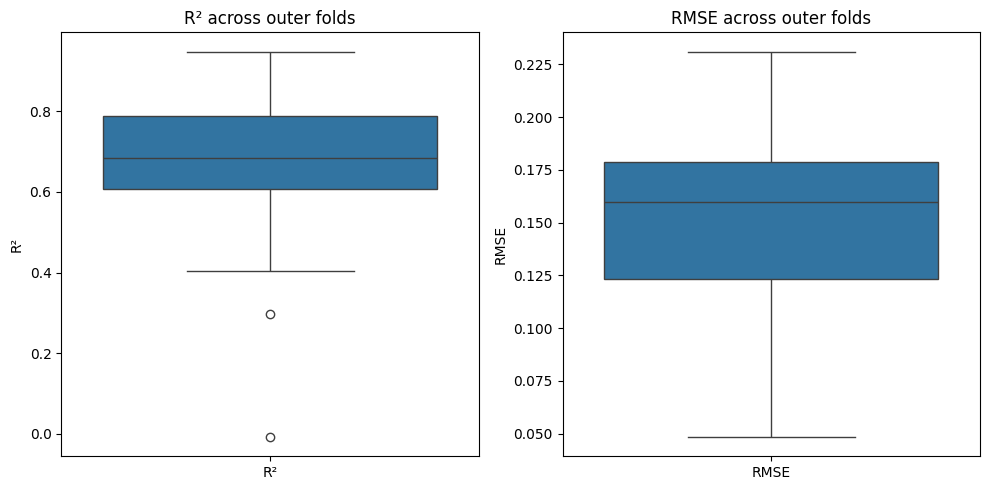

In [38]:
# adjust this to pull all from results since we have multiple repeats now
# Extract metrics
r2_scores = [r2 for repeat in results for _, r2, _ in repeat]
rmse_scores = [rmse for repeat in results for _, _, rmse in repeat]

# Set up figure
plt.figure(figsize=(10, 5))

# R² boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=r2_scores)
plt.title("R² across outer folds")
plt.ylabel("R²")
plt.xticks([0], ["R²"])

# RMSE boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=rmse_scores)
plt.title("RMSE across outer folds")
plt.ylabel("RMSE")
plt.xticks([0], ["RMSE"])

plt.tight_layout()
plt.show()

In [40]:
# adjust this as pulling from results with multiple repeats

r2_means = [np.mean([r2 for _, r2, _ in repeat]) for repeat in results]
rmse_values = [np.mean([rmse for _, _, rmse in repeat]) for repeat in results]

# Compute overall averages
avg_r2 = np.mean(r2_means)
avg_rmse = np.mean(rmse_values)

print(f"Average R²: {avg_r2:.3f}")
print(f"Average RMSE: {avg_rmse:.3f}")

Average R²: 0.656
Average RMSE: 0.151


In [41]:
# save performance metrics (mean, median, and sd) of R² and RMSE across outer folds to feather file
r2_mean = np.mean(r2_scores)
r2_median = np.median(r2_scores)
r2_sd = np.std(r2_scores)
rmse_mean = np.mean(rmse_scores)
rmse_median = np.median(rmse_scores)
rmse_sd = np.std(rmse_scores)
performance_df = pd.DataFrame({
    'metric': ['R²', 'RMSE'],
    'mean': [r2_mean, rmse_mean],
    'median': [r2_median, rmse_median],
    'sd': [r2_sd, rmse_sd]
})

performance_df.to_feather(project_root / '00_data' / 'nn_performance_metrics_scRNA_removed.feather')


# Final model

Having assessed the performance of the model using nested cross-validation, the final model is trained on the entire dataset. The tuning process is repeated using the same hyperparamater grid as before combined with five-fold cross-validation.

In [22]:
device = 'cpu'

# === Hyperparameter grid ===
lr_options = [1e-2, 1e-3, 1e-4]
hidden_options = [32, 64, 128]
final_hidden_options = [32, 64, 128]
param_grid = list(product(lr_options, hidden_options, final_hidden_options))

num_epochs = 100
cv_splits = 5

# === K-fold CV for hyperparameter tuning ===
kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
best_score, best_params = -np.inf, None

for lr, hidden_dim, final_hidden in param_grid:
    fold_scores = []

    for train_idx, val_idx in kf.split(target_tensor):
        # Prepare fold data
        Xs_train = [X[train_idx].to(device) for X in modality_matrices]
        Ms_train = [M[train_idx].to(device) for M in modality_masks]
        y_train = target_tensor[train_idx].to(device)

        Xs_val = [X[val_idx].to(device) for X in modality_matrices]
        Ms_val = [M[val_idx].to(device) for M in modality_masks]
        y_val = target_tensor[val_idx].to(device)

        # Create model & optimizer
        model = MultiBranchMLP([X.shape[1] for X in modality_matrices], hidden_dim=hidden_dim, final_hidden=final_hidden)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()

        # Train
        model.to(device)
        for epoch in range(num_epochs):
            model.train()
            optimizer.zero_grad()
            y_pred_train = model(Xs_train, Ms_train)
            loss = criterion(y_pred_train, y_train)
            loss.backward()
            optimizer.step()

        # Validate
        model.eval()
        with torch.no_grad():
            y_pred_val = model(Xs_val, Ms_val).cpu().numpy()
            y_true_val = y_val.cpu().numpy()
            r2 = r2_score(y_true_val, y_pred_val)
        fold_scores.append(r2)

    avg_score = np.mean(fold_scores)
    if avg_score > best_score:
        best_score = avg_score
        best_params = (lr, hidden_dim, final_hidden)

print(f"Best hyperparameters: lr={best_params[0]}, hidden_dim={best_params[1]}, final_hidden={best_params[2]}, CV R²={best_score:.3f}")

# === Train final model on all data with best hyperparameters ===
lr, hidden_dim, final_hidden = best_params
model = MultiBranchMLP([X.shape[1] for X in modality_matrices], hidden_dim=hidden_dim, final_hidden=final_hidden)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

Xs_full = [X.to(device) for X in modality_matrices]
Ms_full = [M.to(device) for M in modality_masks]
y_full = target_tensor.to(device)

model.to(device)
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(Xs_full, Ms_full)
    loss = criterion(y_pred_train, y_full)
    loss.backward()
    optimizer.step()

print("Final model trained on all data.")

Best hyperparameters: lr=0.01, hidden_dim=32, final_hidden=64, CV R²=0.832
Final model trained on all data.


## Feature importances

The feature importances here are calculated using global SHAP values (the importance of each feature to the entire model). The scRNA features rank highly, partly by design as modalities with more features are given larger hidden dimensions in the network branches.

C:\Users\joddy\repos\multiomics_integration_publication\.venv\lib\site-packages\captum\attr\_core\deep_lift.py:810: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  attributions = super().attribute.__wrapped__(  # type: ignore


   branch                     feature  importance
0    LCMS  4-Hydroxyphenyllactic acid    0.005923
1    LCMS        Methionine sulfoxide    0.005431
2    LCMS                   Thymidine    0.005343
3    LCMS                 Niacinamide    0.005116
4    LCMS                  Putrescine    0.004658
5    LCMS                     Inosine    0.004530
6    LCMS                  Xanthosine    0.004394
7    LCMS         2-Aminobutyric acid    0.004306
8    LCMS         Anthranilic acid(+)    0.004239
9   miRNA             ENSG00000216060    0.004060
10  miRNA             ENSG00000265201    0.003854
11   LCMS               Glutamic acid    0.003572
12   LCMS                     Glycine    0.003569
13  miRNA             ENSG00000264342    0.003559
14   LCMS               Glyceric acid    0.003514
15   LCMS                 Glutathione    0.003401
16   LCMS                  Isoleucine    0.003285
17   LCMS                   Histidine    0.003265
18  miRNA             ENSG00000263813    0.003264


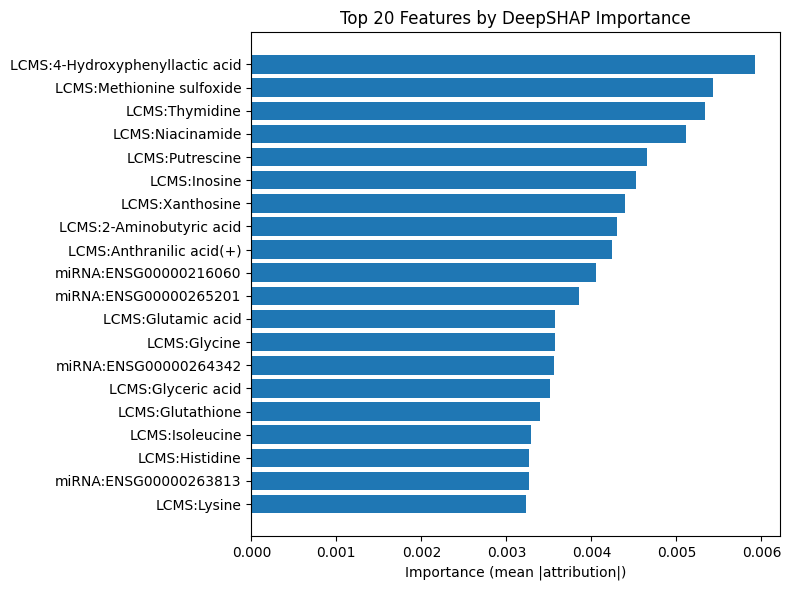

In [23]:
feature_names = [
    list(miRNA_data.columns),
    list(olink_data.columns),
    list(lcms_data.columns)
]

branch_names = ["miRNA", "Olink", "LCMS"]

# === Wrapper so Captum can use flat inputs ===
class ModelWrapper(torch.nn.Module):
    def __init__(self, model, n_branches):
        super().__init__()
        self.model = model
        self.n_branches = n_branches

    def forward(self, *flat_inputs):
        Xs = flat_inputs[:self.n_branches]
        Ms = flat_inputs[self.n_branches:]
        out = self.model(Xs, Ms)
        if isinstance(out, tuple):
            out = out[0]
        return out

# === Prepare inputs & baselines ===
n_branches = len(Xs_full)

inputs = tuple(list(Xs_full) + list(Ms_full))
baselines = tuple(
    [torch.zeros_like(x) for x in Xs_full] +
    [m for m in Ms_full]  # keep masks fixed
)

wrapped_model = ModelWrapper(model, n_branches=n_branches).eval()
explainer = DeepLiftShap(wrapped_model)

# === Compute attributions ===
attributions = explainer.attribute(
    inputs=inputs,
    baselines=baselines,
    target=None  # regression scalar
)

# === Split out feature attributions (ignore masks) ===
Xs_attr = attributions[:n_branches]

# === Mean absolute importance per feature ===
branch_importances = [
    attr.abs().mean(dim=0).detach().cpu().numpy() for attr in Xs_attr
]

# === Build DataFrame with labels ===
rows = []
for branch_id, importances in enumerate(branch_importances):
    bname = branch_names[branch_id]
    for feat_id, score in enumerate(importances):
        fname = feature_names[branch_id][feat_id]
        rows.append({
            "branch": bname,
            "feature": fname,
            "importance": score
        })

df_importances = pd.DataFrame(rows)
df_importances.sort_values("importance", ascending=False, inplace=True)
df_importances.reset_index(drop=True, inplace=True)

print(df_importances.head(20))  # top 20 features

# === Plot top N ===
top_n = 20
top_df = df_importances.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(
    y=[f"{row.branch}:{row.feature}" for row in top_df.itertuples()],
    width=top_df["importance"],
)
plt.gca().invert_yaxis()  # biggest at top
plt.xlabel("Importance (mean |attribution|)")
plt.title(f"Top {top_n} Features by DeepSHAP Importance")
plt.tight_layout()
plt.show()


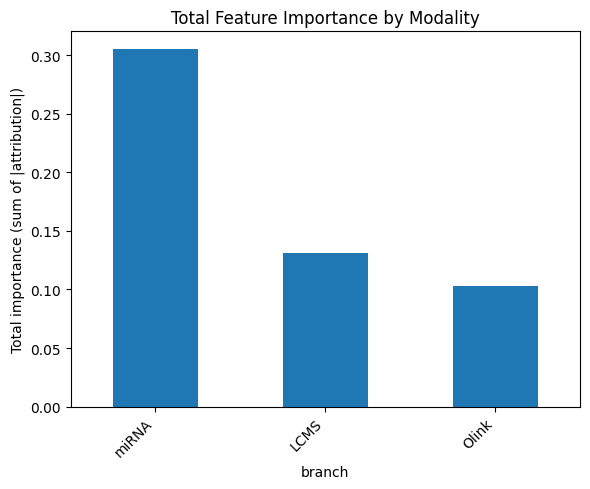

In [24]:
# === Aggregate by branch (sum of importances) ===
branch_totals = (
    df_importances.groupby("branch")["importance"]
    .sum()
    .sort_values(ascending=False)
)

# === Plot ===
plt.figure(figsize=(6, 5))
branch_totals.plot(kind="bar")
plt.ylabel("Total importance (sum of |attribution|)")
plt.title("Total Feature Importance by Modality")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


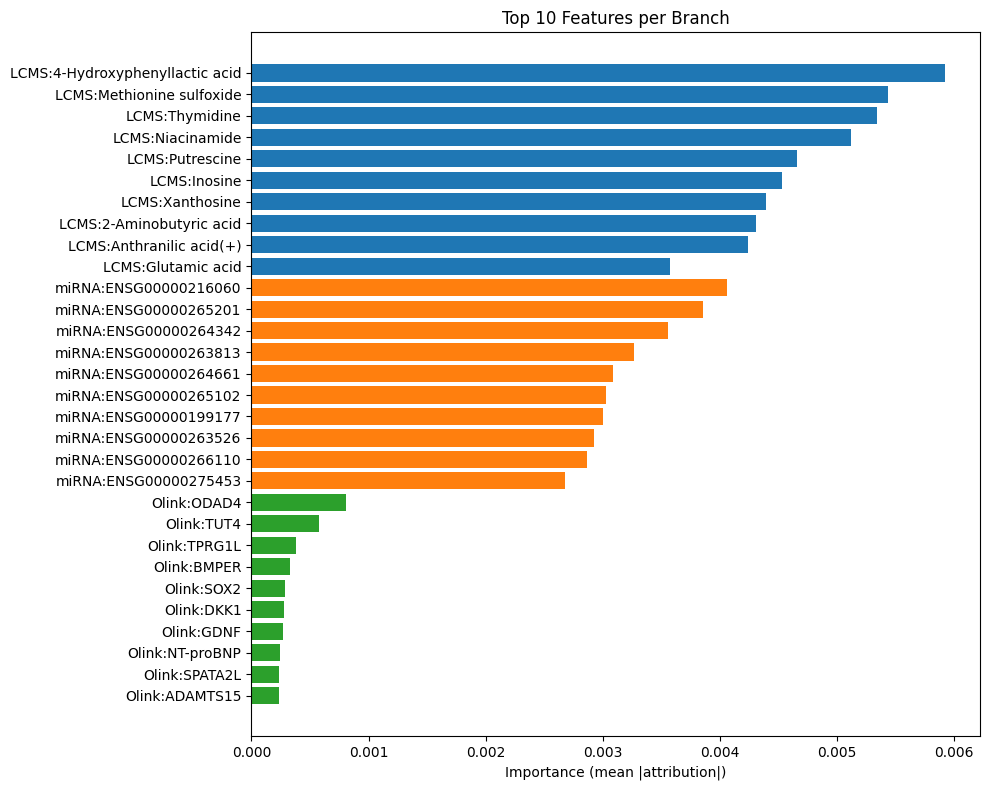

In [25]:
top_n = 10
plt.figure(figsize=(10, 8))

# Loop over branches
for i, branch in enumerate(df_importances['branch'].unique()):
    top_features = (
        df_importances[df_importances['branch'] == branch]
        .nlargest(top_n, 'importance')
    )
    
    plt.barh(
        y=[f"{branch}:{f}" for f in top_features['feature']],
        width=top_features['importance'],
        label=branch
    )

plt.xlabel("Importance (mean |attribution|)")
plt.title(f"Top {top_n} Features per Branch")
plt.gca().invert_yaxis()  # largest at top
plt.tight_layout()
plt.show()


## Model architecture

This section visualises the architecture of the model implemented above.

In [26]:
from torchinfo import summary

# Provide example inputs for each modality
example_inputs = [torch.randn(1, X.shape[1]) for X in modality_matrices]  # batch size = 1
example_masks  = [torch.randn(1, X.shape[1]) for X in modality_matrices]

summary(model, input_data=(example_inputs, example_masks))


Layer (type:depth-idx)                   Output Shape              Param #
MultiBranchMLP                           [1]                       --
├─ModuleList: 1-1                        --                        --
│    └─MaskedBranch: 2-1                 [1, 22]                   --
│    │    └─Sequential: 3-1              [1, 22]                   15,312
│    └─MaskedBranch: 2-2                 [1, 69]                   --
│    │    └─Sequential: 3-2              [1, 69]                   144,279
│    └─MaskedBranch: 2-3                 [1, 8]                    --
│    │    └─Sequential: 3-3              [1, 8]                    1,008
├─Sequential: 1-2                        [1, 1]                    --
│    └─Linear: 2-4                       [1, 64]                   6,400
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Linear: 2-6                       [1, 1]                    65
Total params: 167,064
Trainable params: 167,064
Non-trainable params: 


(process:13120): Pango-WARNING **: 13:08:18.432: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


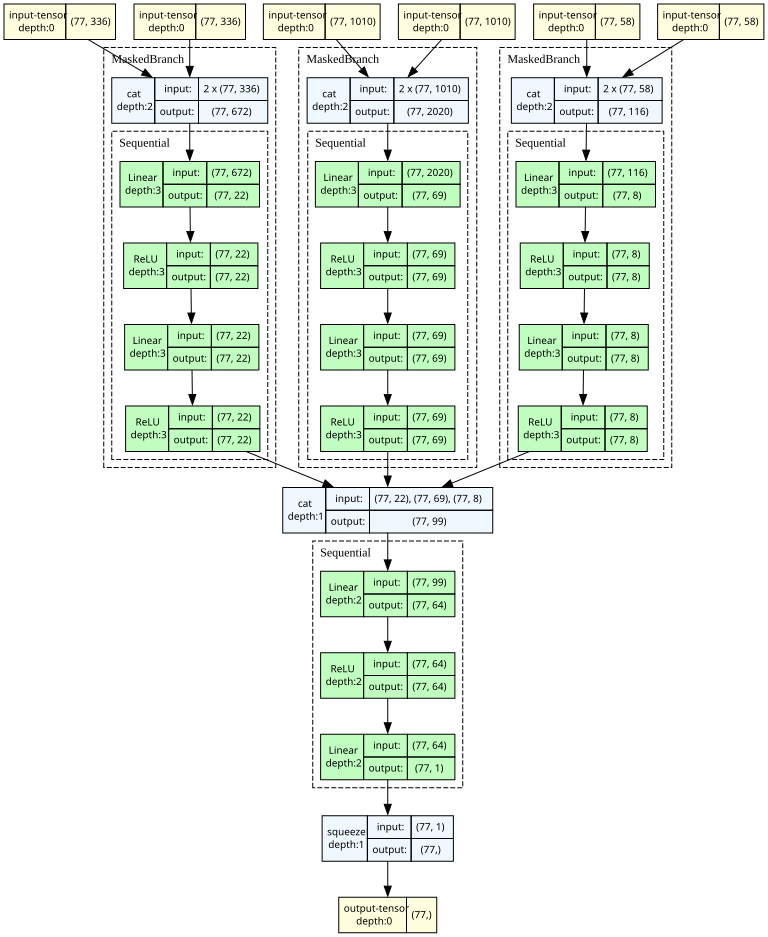

In [27]:
# === Use all your data as input ===
Xs_full = [X.to(device) for X in modality_matrices]
Ms_full = [M.to(device) for M in modality_masks]

# torchview expects a tuple matching the forward signature
input_data = (Xs_full, Ms_full)

# Generate graph with full input dimensions
model_graph = draw_graph(
    model,
    input_data=input_data,
    expand_nested=True,   # unfold submodules like MaskedBranch
    depth=5,              # how deep to expand
    save_graph=False,
    device=device,
)

# Show inline
model_graph.visual_graph

In [29]:
# the feature importances calculated in this notebook are saved here for comparison with other feature importances from the different multiomics integration strategies
df_importances.reset_index().to_feather(project_root / '00_data' / 'feature_importances' / 'neural_network_importances_scRNA_removed.feather')